In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

sns.set_theme(style='whitegrid')

In [19]:
aisles         = pd.read_csv('./datasets/aisles.csv')
departments    = pd.read_csv('./datasets/departments.csv')
products       = pd.read_csv('./datasets/products.csv')
orders         = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv')

## EDA

### Quelles sont les pics d'affluences dans la semaine ?

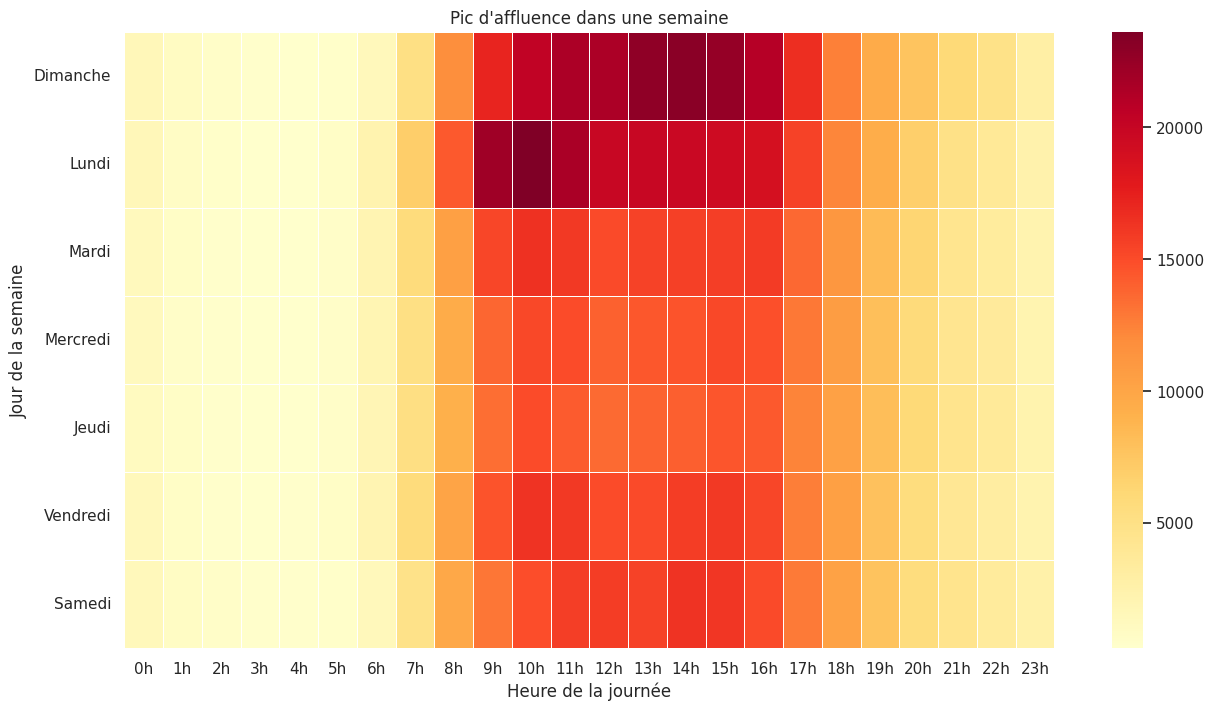

In [ ]:

cols = ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


orders = pd.read_csv('./datasets/orders.csv', skiprows=1, names=cols)
group_day_hour=orders.groupby(["order_dow", "order_hour_of_day"])["order_id"].count().reset_index()

orders_tab=group_day_hour.pivot(index='order_dow', columns='order_hour_of_day', values='order_id')


plt.figure(figsize=(15, 8))
sns.heatmap(orders_tab, cmap="YlOrRd", linewidths=.5)

plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
           labels=['Dimanche', 'Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi'], 
           rotation=0)


heures_positions = [i + 0.5 for i in range(24)]
heures_labels = [f"{i}h" for i in range(24)]
plt.xticks(ticks=heures_positions, labels=heures_labels, rotation=0)


plt.title("Pic d'affluence dans une semaine")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()


In [21]:


orders_tab.describe()

order_hour_of_day,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,1372.571429,744.714286,455.428571,325.714286,335.000000,580.285714,1856.571429,5526.714286,10733.714286,15602.142857,...,17060.857143,17107.714286,16481.714286,13795.000000,11083.285714,8467.857143,6264.000000,4674.428571,3728.428571,2389.285714
std,177.107178,136.821921,85.582041,53.881705,34.765884,82.741997,322.407019,723.095133,1807.995272,3184.782328,...,3240.917176,2899.688243,2485.006285,1662.674252,942.191544,748.647542,771.566804,636.138050,555.782888,229.872946
min,1100.000000,591.000000,377.000000,260.000000,292.000000,472.000000,1398.000000,4737.000000,9134.000000,13039.000000,...,14058.000000,14525.000000,14371.000000,12317.000000,10222.000000,7766.000000,5610.000000,4066.000000,3119.000000,2156.000000
25%,1281.500000,660.000000,396.500000,293.000000,311.000000,528.500000,1654.500000,5166.000000,9654.500000,13529.500000,...,15159.500000,15445.000000,14963.000000,12756.000000,10364.500000,7963.000000,5727.500000,4377.000000,3478.000000,2248.000000
50%,1365.000000,679.000000,410.000000,310.000000,339.000000,578.000000,1951.000000,5265.000000,10147.000000,14596.000000,...,15804.000000,16025.000000,15291.000000,12907.000000,10675.000000,8155.000000,5934.000000,4473.000000,3572.000000,2316.000000
75%,1485.500000,818.000000,507.500000,354.000000,349.500000,634.000000,2035.500000,5682.500000,11094.000000,16217.500000,...,18050.500000,17849.000000,17394.000000,14569.000000,11726.000000,8907.000000,6567.000000,4723.000000,3792.000000,2464.000000
max,1609.000000,987.000000,593.000000,416.000000,393.000000,687.000000,2267.000000,6988.000000,14358.000000,22086.000000,...,23144.000000,22616.000000,20996.000000,16691.000000,12505.000000,9614.000000,7715.000000,5982.000000,4868.000000,2829.000000


## Modèles